In [1]:
input_ohlcv_file = "stables1d.parquet"
market_symbol = "BTCUSDT"

output_features_file = "features.parquet"
output_summary_file = "feature_summary.csv"

In [2]:
# prepare data
import polars as pl
import random
import torch
import numpy as np

eps = 1e-8

market = (
    pl.scan_parquet(input_ohlcv_file)
    .filter(pl.col("symbol") == market_symbol)
    .sort("ts")
    .filter(
        (pl.col("open") > 0)
        & (pl.col("high") > 0)
        & (pl.col("low") > 0)
        & (pl.col("close") > 0)
        & (pl.col("base_volume") > 0)
        & (pl.col("quote_volume") > 0)
    )
    .with_columns(
        ref=(pl.col("close") / pl.col("open")).log(),
        ref_cc=(pl.col("close") / pl.col("close").shift(1)).log(),
        ref_range=(pl.col("high") / pl.col("low")).log(),
    )
    .with_columns(
        ref_mom_3=pl.col("ref").rolling_sum(window_size=3),
        ref_mom_7=pl.col("ref").rolling_sum(window_size=7),
        ref_mom_30=pl.col("ref").rolling_sum(window_size=30),
        ref_vol_7=pl.col("ref").rolling_std(window_size=7),
        ref_vol_30=pl.col("ref").rolling_std(window_size=30),
    )
    .select(
        [
            "ts",
            "ref",
            "ref_cc",
            "ref_range",
            "ref_mom_3",
            "ref_mom_7",
            "ref_mom_30",
            "ref_vol_7",
            "ref_vol_30",
        ]
    )
)

features = (
    pl.scan_parquet(input_ohlcv_file)
    .sort(["symbol", "ts"])
    .filter(
        (pl.col("open") > 0)
        & (pl.col("high") > 0)
        & (pl.col("low") > 0)
        & (pl.col("close") > 0)
        & (pl.col("base_volume") > 0)
        & (pl.col("quote_volume") > 0)
    )
    .join(market, on="ts", how="inner")
    .sort(["symbol", "ts"])
    .with_columns(
        # base returns
        ret=(pl.col("close") / pl.col("open")).log(),
        cc_ret=(pl.col("close") / pl.col("close").shift(1)).log().over("symbol"),
        gap=(pl.col("open") / pl.col("close").shift(1)).log().over("symbol"),
        target=(pl.col("close").shift(-1) / pl.col("open").shift(-1))
        .log()
        .over("symbol"),
        # bar structure
        hl_range=(pl.col("high") / pl.col("low")).log(),
        close_loc=(
            2.0
            * (
                (pl.col("close") - pl.col("low"))
                / (pl.col("high") - pl.col("low") + pl.lit(eps))
            )
            - 1.0
        ),
        body_frac=(
            (pl.col("close") - pl.col("open"))
            / (pl.col("high") - pl.col("low") + pl.lit(eps))
        ),
        upper_wick_frac=(
            (pl.col("high") - pl.max_horizontal("open", "close"))
            / (pl.col("high") - pl.col("low") + pl.lit(eps))
        ),
        lower_wick_frac=(
            (pl.min_horizontal("open", "close") - pl.col("low"))
            / (pl.col("high") - pl.col("low") + pl.lit(eps))
        ),
        wick_asym=(
            (pl.col("high") - pl.max_horizontal("open", "close") + pl.lit(eps))
            / (pl.min_horizontal("open", "close") - pl.col("low") + pl.lit(eps))
        ).log(),
        # range-based vol
        sigma_rs=(
            (
                (pl.col("high") / pl.col("close")).log()
                * (pl.col("high") / pl.col("open")).log()
            )
            + (
                (pl.col("low") / pl.col("close")).log()
                * (pl.col("low") / pl.col("open")).log()
            )
        ).sqrt(),
        # volume / participation
        vwap=pl.col("quote_volume") / (pl.col("base_volume") + pl.lit(eps)),
        vwap_close=(
            pl.col("close")
            / (pl.col("quote_volume") / (pl.col("base_volume") + pl.lit(eps)))
        ).log(),
        vwap_open=(
            (pl.col("quote_volume") / (pl.col("base_volume") + pl.lit(eps)))
            / pl.col("open")
        ).log(),
        log_quote_vol=(pl.col("quote_volume") + pl.lit(eps)).log(),
        log_base_vol=(pl.col("base_volume") + pl.lit(eps)).log(),
        # order-flow proxy in quote units
        flow_imb=(2.0 * pl.col("taker_buy_quote_volume") - pl.col("quote_volume"))
        / (pl.col("quote_volume") + pl.lit(eps)),
    )
    .with_columns(
        # market-relative features
        ret_rel=pl.col("ret") - pl.col("ref"),
        cc_ret_rel=pl.col("cc_ret") - pl.col("ref_cc"),
        range_rel=pl.col("hl_range") - pl.col("ref_range"),
    )
    .with_columns(
        # momentum
        mom_3=pl.col("ret").rolling_sum(window_size=3).over("symbol"),
        mom_7=pl.col("ret").rolling_sum(window_size=7).over("symbol"),
        mom_14=pl.col("ret").rolling_sum(window_size=14).over("symbol"),
        mom_30=pl.col("ret").rolling_sum(window_size=30).over("symbol"),
        mom_90=pl.col("ret").rolling_sum(window_size=90).over("symbol"),
        # residual / relative momentum
        rel_mom_3=pl.col("ret_rel").rolling_sum(window_size=3).over("symbol"),
        rel_mom_7=pl.col("ret_rel").rolling_sum(window_size=7).over("symbol"),
        rel_mom_30=pl.col("ret_rel").rolling_sum(window_size=30).over("symbol"),
        # realized vol
        rv_7=pl.col("ret").rolling_std(window_size=7).over("symbol"),
        rv_30=pl.col("ret").rolling_std(window_size=30).over("symbol"),
        rv_90=pl.col("ret").rolling_std(window_size=90).over("symbol"),
        # volume baselines
        log_quote_vol_mean_7=pl.col("log_quote_vol")
        .rolling_mean(window_size=7)
        .over("symbol"),
        log_quote_vol_std_7=pl.col("log_quote_vol")
        .rolling_std(window_size=7)
        .over("symbol"),
        log_quote_vol_mean_30=pl.col("log_quote_vol")
        .rolling_mean(window_size=30)
        .over("symbol"),
        log_quote_vol_std_30=pl.col("log_quote_vol")
        .rolling_std(window_size=30)
        .over("symbol"),
        # flow baselines
        flow_imb_mean_7=pl.col("flow_imb").rolling_mean(window_size=7).over("symbol"),
        flow_imb_mean_30=pl.col("flow_imb").rolling_mean(window_size=30).over("symbol"),
    )
    .with_columns(
        # vol-adjusted momentum
        mom_7_voladj=pl.col("mom_7") / (pl.col("rv_7") + pl.lit(eps)),
        mom_30_voladj=pl.col("mom_30") / (pl.col("rv_30") + pl.lit(eps)),
        rel_mom_7_voladj=pl.col("rel_mom_7") / (pl.col("rv_7") + pl.lit(eps)),
        rel_mom_30_voladj=pl.col("rel_mom_30") / (pl.col("rv_30") + pl.lit(eps)),
        # vol regime
        vol_ratio_7_30=pl.col("rv_7") / (pl.col("rv_30") + pl.lit(eps)),
        vol_ratio_30_90=pl.col("rv_30") / (pl.col("rv_90") + pl.lit(eps)),
        # volume surprise
        vol_z_7=(
            (pl.col("log_quote_vol") - pl.col("log_quote_vol_mean_7"))
            / (pl.col("log_quote_vol_std_7") + pl.lit(eps))
        ),
        vol_z_30=(
            (pl.col("log_quote_vol") - pl.col("log_quote_vol_mean_30"))
            / (pl.col("log_quote_vol_std_30") + pl.lit(eps))
        ),
        rel_volume_7=pl.col("quote_volume")
        / (
            pl.col("quote_volume").rolling_mean(window_size=7).over("symbol")
            + pl.lit(eps)
        ),
        rel_volume_30=pl.col("quote_volume")
        / (
            pl.col("quote_volume").rolling_mean(window_size=30).over("symbol")
            + pl.lit(eps)
        ),
        # flow surprise / persistence
        flow_dev_7=pl.col("flow_imb") - pl.col("flow_imb_mean_7"),
        flow_dev_30=pl.col("flow_imb") - pl.col("flow_imb_mean_30"),
        # trend quality
        trend_intensity=pl.col("ret") / (pl.col("hl_range") + pl.lit(eps)),
        rel_trend_intensity=pl.col("ret_rel") / (pl.col("hl_range") + pl.lit(eps)),
    )
    .with_columns(
        # cross-sectional ranks, centered around 0
        ret_cs=((pl.col("ret").rank().over("ts") / pl.len().over("ts")) - 0.5),
        ret_rel_cs=((pl.col("ret_rel").rank().over("ts") / pl.len().over("ts")) - 0.5),
        mom_7_cs=((pl.col("mom_7").rank().over("ts") / pl.len().over("ts")) - 0.5),
        mom_30_cs=((pl.col("mom_30").rank().over("ts") / pl.len().over("ts")) - 0.5),
        rel_mom_7_cs=(
            (pl.col("rel_mom_7").rank().over("ts") / pl.len().over("ts")) - 0.5
        ),
        rel_mom_30_cs=(
            (pl.col("rel_mom_30").rank().over("ts") / pl.len().over("ts")) - 0.5
        ),
        rv_30_cs=((pl.col("rv_30").rank().over("ts") / pl.len().over("ts")) - 0.5),
        vol_z_30_cs=(
            (pl.col("vol_z_30").rank().over("ts") / pl.len().over("ts")) - 0.5
        ),
        flow_imb_cs=(
            (pl.col("flow_imb").rank().over("ts") / pl.len().over("ts")) - 0.5
        ),
        close_loc_cs=(
            (pl.col("close_loc").rank().over("ts") / pl.len().over("ts")) - 0.5
        ),
    )
    .select(
        [
            # base columns
            "ts",
            "symbol",
            "target",
            # market state
            "ref",
            "ref_cc",
            "ref_range",
            "ref_mom_3",
            "ref_mom_7",
            "ref_mom_30",
            "ref_vol_7",
            "ref_vol_30",
            # own returns / relative returns
            "ret",
            "cc_ret",
            "gap",
            "ret_rel",
            "cc_ret_rel",
            "range_rel",
            # bar structure
            "hl_range",
            "close_loc",
            "body_frac",
            "upper_wick_frac",
            "lower_wick_frac",
            "wick_asym",
            "sigma_rs",
            "trend_intensity",
            "rel_trend_intensity",
            # volume / execution / flow
            "vwap_close",
            "vwap_open",
            "log_quote_vol",
            "log_base_vol",
            "flow_imb",
            "flow_dev_7",
            "flow_dev_30",
            "vol_z_7",
            "vol_z_30",
            "rel_volume_7",
            "rel_volume_30",
            # momentum / vol
            "mom_3",
            "mom_7",
            "mom_14",
            "mom_30",
            "mom_90",
            "rel_mom_3",
            "rel_mom_7",
            "rel_mom_30",
            "rv_7",
            "rv_30",
            "rv_90",
            "mom_7_voladj",
            "mom_30_voladj",
            "rel_mom_7_voladj",
            "rel_mom_30_voladj",
            "vol_ratio_7_30",
            "vol_ratio_30_90",
            # cross-sectional context
            "ret_cs",
            "ret_rel_cs",
            "mom_7_cs",
            "mom_30_cs",
            "rel_mom_7_cs",
            "rel_mom_30_cs",
            "rv_30_cs",
            "vol_z_30_cs",
            "flow_imb_cs",
            "close_loc_cs",
        ]
    )
).sink_parquet(output_features_file)

In [3]:
import polars.selectors as cs
import polars as pl
import math

df = pl.read_parquet(output_features_file)

feature_cols = sorted(
    [
        col
        for col in df.columns
        if col
        not in [
            "ts",
            "symbol",
            "target",
            "ref",
            "ref_cc",
            "ref_range",
            "ref_mom_3",
            "ref_mom_7",
            "ref_mom_30",
            "ref_vol_7",
            "ref_vol_30",
        ]
    ]
)


def daily_rank_ic(df: pl.DataFrame, feature: str, min_n: int = 20) -> pl.DataFrame:
    out = (
        df.select(["ts", "symbol", feature, "target"])
        .drop_nulls([feature, "target"])
        .with_columns(
            x_rank=pl.col(feature).rank("average").over("ts"),
            y_rank=pl.col("target").rank("average").over("ts"),
        )
        .group_by("ts")
        .agg(
            n=pl.len(),
            x_std=pl.col("x_rank").std(),
            y_std=pl.col("y_rank").std(),
            ic=pl.corr("x_rank", "y_rank"),
        )
        .with_columns(
            ic=pl.when(
                (pl.col("n") >= min_n)
                & (pl.col("x_std") > 0)
                & (pl.col("y_std") > 0)
                & (pl.col("ic").is_finite())
            )
            .then(pl.col("ic"))
            .otherwise(None)
        )
        .sort("ts")
    )
    return out


summary_rows = []

for f in feature_cols:
    ic_df = daily_rank_ic(df, f, min_n=20)

    valid = ic_df.drop_nulls(["ic"])
    n_total = ic_df.height
    n_valid = valid.height
    n_invalid = n_total - n_valid

    if n_valid == 0:
        summary_rows.append(
            {
                "feature": f,
                "mean_ic": None,
                "std_ic": None,
                "icir": None,
                "tstat": None,
                "hit_rate": None,
                "n_total": n_total,
                "n_valid": n_valid,
                "n_invalid": n_invalid,
            }
        )
        continue

    mean_ic = valid["ic"].mean()
    std_ic = valid["ic"].std()
    icir = mean_ic / std_ic if std_ic and std_ic > 0 else None
    tstat = (
        (mean_ic / (std_ic / math.sqrt(n_valid)))
        if std_ic and std_ic > 0 and n_valid > 1
        else None
    )
    hit_rate = (valid["ic"] > 0).mean()

    summary_rows.append(
        {
            "feature": f,
            "mean_ic": mean_ic,
            "std_ic": std_ic,
            "icir": icir,
            "tstat": tstat,
            "hit_rate": hit_rate,
            "n_total": n_total,
            "n_valid": n_valid,
            "n_invalid": n_invalid,
        }
    )

ic_summary = pl.DataFrame(summary_rows).sort("mean_ic", descending=True)
print(ic_summary.write_csv())

feature,mean_ic,std_ic,icir,tstat,hit_rate,n_total,n_valid,n_invalid
lower_wick_frac,0.0277617520799482,0.13924915305598964,0.19936747528213467,10.386260973218956,0.5899042004421519,3129,2714,415
gap,0.0027463980409921525,0.09796086681466142,0.0280356649578065,1.460009574662694,0.5117994100294986,3128,2712,416
flow_imb,-0.009610296705100503,0.11246867411873561,-0.08544865297295766,-4.451538588885808,0.4340456890198968,3129,2714,415
flow_imb_cs,-0.009610296705100503,0.11246867411873561,-0.08544865297295766,-4.451538588885808,0.4340456890198968,3129,2714,415
upper_wick_frac,-0.014730194285571622,0.13877420347825523,-0.10614504653150268,-5.529739255264808,0.4436256448047163,3129,2714,415
flow_dev_7,-0.01651907625864542,0.1031933928689461,-0.160078817057836,-8.321019478769342,0.4133974833456699,3123,2702,421
close_loc,-0.019617337049356354,0.15077996251602133,-0.1301057297137336,-6.777996566418958,0.4447310243183493,3129,2714,415
close_loc_cs,-0.019617337049356354,0.15077996251602133,-0.13

In [4]:
from sklearn.linear_model import Ridge
import pandas as pd
from tqdm import tqdm

selected_features = [
    # Vol / range family
    "rv_7",
    "rv_30",
    "rv_90",
    "sigma_rs",
    "hl_range",
    # Volume / participation / attention family
    "vol_z_30",
    "rel_volume_30",
    "log_quote_vol",
    "log_base_vol",
    # Short-horizon reversal family
    "mom_3",
    "rel_mom_3",
    "ret",
    "cc_ret",
    # Candle-structure family
    "lower_wick_frac",
    "wick_asym",
    "upper_wick_frac",
]

winsor_q = 0.01
alpha = 0.1  # try 1,10,100
min_symbols = 20
fee_rate = 0.002  # 0.2% entry and exit fee (0.4% total)
n_days = 5

df = (
    pl.read_parquet(output_features_file)
    # Sort before computing multi-day targets to ensure time series integrity
    .sort(["symbol", "ts"])
    .with_columns(
        [
            (
                pl.col("ret").shift(-1).over("symbol")
                + (
                    pl.col("cc_ret")
                    .shift(-2)
                    .over("symbol")
                    .rolling_sum(window_size=i - 1)
                    .shift(-(i - 2))
                    .over("symbol")
                    if i > 1
                    else 0
                )
            ).alias(f"target_d{i}")
            for i in range(1, n_days + 1)
        ]
    )
    .select(
        list(selected_features)
        + ["ts", "target", "symbol"]
        + [f"target_d{i}" for i in range(1, n_days + 1)]
    )
    .fill_null(np.nan)
    .drop_nans(["target", *selected_features] + [f"target_d{i}" for i in range(1, n_days + 1)])
    .filter(pl.len().over("ts") >= min_symbols)
    # winsorize cross-sectionally
    .with_columns(
        [
            pl.col(f)
            .clip(
                pl.col(f).quantile(winsor_q),
                pl.col(f).quantile(1 - winsor_q),
            )
            .over("ts")
            for f in selected_features
        ]
    )
    # rank cross-sectionally -0.5/0.5
    .with_columns(
        [
            (pl.col(f).rank("average").over("ts") / pl.len().over("ts")) - 0.5
            for f in selected_features
        ]
    )
    .sort(["ts", "symbol"])
)

# feature correlation
# df_corr = pd.DataFrame(
#    np.corrcoef(df.select(selected_features).to_numpy(), rowvar=False),
#    index=selected_features,
#    columns=selected_features,
# )
# print(df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool)))


def evaluate(
    df: pl.DataFrame,
    alpha: float,
    features: list[str],
    net_features: list[str],
    n_days: int,
) -> pl.DataFrame:
    net_features = [f for f in features if f in net_features]
    target_cols = [f"target_d{i}" for i in range(1, n_days + 1)]
    net_df = df.select(["ts", "symbol", "target"] + target_cols + net_features)

    ts = net_df["ts"].unique().sort().to_list()
    train_ts = ts[: int(len(ts) * 0.8)]
    test_ts = ts[int(len(ts) * 0.8) :]
    train_df = net_df.filter(pl.col("ts") <= train_ts[-1])
    test_df = net_df.filter(
        (pl.col("ts") >= test_ts[0]) & (pl.col("ts") <= test_ts[-1])
    )

    X = train_df.select(net_features).to_numpy()
    y = train_df["target"].to_numpy()

    model = Ridge(alpha=alpha)
    model.fit(X, y)

    coef = model.coef_
    for f in features:
        if f in net_features:
            continue
        skip_index = features.index(f)
        coef = np.insert(coef, skip_index, np.nan)
    assert len(coef) == len(features)

    prediction = test_df.with_columns(
        pred=model.predict(test_df.select(net_features).to_numpy())
    )

    # evaluate signal quality with daily IC for each day
    ic_exprs = [
        pl.corr(
            pl.col("pred").rank("average").over("ts"),
            pl.col(f"target_d{i}").rank("average").over("ts"),
        ).alias(f"ic_d{i}")
        for i in range(1, n_days + 1)
    ]

    signal_ts = (
        prediction.group_by("ts").agg(ic_exprs + [pl.len().alias("n")]).sort("ts")
    )

    # Filter signal_ts to remove rows with any NaN in ic_d columns for mean/std calculation
    signal_valid = signal_ts.drop_nulls()

    signal = signal_valid.select(
        [pl.lit(alpha).alias("alpha")]
        + [
            item
            for i in range(1, n_days + 1)
            for item in [
                pl.col(f"ic_d{i}").mean().alias(f"ic_d{i}"),
                pl.col(f"ic_d{i}").std().alias(f"ic_d{i}_std"),
            ]
        ]
        + [
            pl.col("ic_d1").mean().alias("mean_ic"),
            pl.col("ic_d1").std().alias("std_ic"),
            (pl.col("ic_d1").mean() / pl.col("ic_d1").std()).alias("icir"),
            (pl.col("ic_d1") > 0).mean().alias("hit_rate"),
            pl.col("n").mean().alias("avg_n"),
        ]
    ).with_columns(
        [pl.lit(coef[i]).alias(f"{features[i]}_coef") for i in range(len(features))]
    )

    # portfolio evaluation with transaction costs
    portfolio_base = (
        prediction
        # portfolio is top decile of predictions, long if pred > 0, short if pred < 0
        .filter(
            (
                pl.col("pred").abs().rank(descending=False).over("ts")
                / pl.len().over("ts")
            )
            > 0.9
        ).with_columns(pos=pl.when(pl.col("pred") > 0).then(1).otherwise(-1))
        # normalize to maintain constant leverage of 1
        .with_columns(pos=pl.col("pos") / pl.col("pos").abs().sum().over("ts"))
    )

    fwdret_exprs = [
        (pl.col("pos") * (pl.col(f"target_d{i}").exp() - 1)).sum().alias(f"fwdret_d{i}")
        for i in range(1, n_days + 1)
    ]

    portfolio_metrics = (
        portfolio_base.with_columns(
            gross=pl.col("pos") * (pl.col("target").exp() - 1),
            fee=2 * pl.col("pos").abs() * fee_rate,
        )
        .with_columns(net=pl.col("gross") - pl.col("fee"))
        .group_by("ts")
        .agg(
            [pl.col("net").sum().alias("net"), pl.col("fee").sum().alias("fee")]
            + fwdret_exprs
        )
        .sort("ts")
    )

    portfolio_summary = portfolio_metrics.select(
        mean_ret=pl.col("net").mean() * 365,
        std_ret=pl.col("net").std() * (365**0.5),
        sharpe=pl.col("net").mean() / pl.col("net").std() * (365**0.5),
        fee=pl.col("fee").mean(),
        equity=(1 + pl.col("net")).cum_prod(),
        *[
            item
            for i in range(1, n_days + 1)
            for item in [
                pl.col(f"fwdret_d{i}").mean().alias(f"fwdret_d{i}"),
                pl.col(f"fwdret_d{i}").std().alias(f"fwdret_d{i}_std"),
            ]
        ],
    ).with_columns(
        mdd=(pl.col("equity") / (pl.col("equity").cum_max() + 1e-12) - 1).min(),
    )

    return signal.with_columns(portfolio_summary.head(1).drop("equity"))


summary = []
for feature in tqdm(selected_features, desc="Evaluating features"):
    summary.append(
        evaluate(df, alpha, selected_features, [feature], n_days).with_columns(
            name=pl.lit(feature)
        )
    )


summary = pl.concat(summary).sort("mean_ret", descending=True)
print(summary)
summary.write_csv(output_summary_file)

Evaluating features: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:01<00:00,  9.70it/s]

shape: (16, 108)
┌───────┬──────────┬───────────┬──────────┬───┬───────────┬───────┬───────────┬─────────────────┐
│ alpha ┆ ic_d1    ┆ ic_d1_std ┆ ic_d2    ┆ … ┆ sharpe    ┆ fee   ┆ mdd       ┆ name            │
│ ---   ┆ ---      ┆ ---       ┆ ---      ┆   ┆ ---       ┆ ---   ┆ ---       ┆ ---             │
│ f64   ┆ f64      ┆ f64       ┆ f64      ┆   ┆ f64       ┆ f64   ┆ f64       ┆ str             │
╞═══════╪══════════╪═══════════╪══════════╪═══╪═══════════╪═══════╪═══════════╪═════════════════╡
│ 0.1   ┆ 0.048784 ┆ 0.193762  ┆ 0.045387 ┆ … ┆ -0.042924 ┆ 0.004 ┆ -0.720287 ┆ cc_ret          │
│ 0.1   ┆ 0.048797 ┆ 0.193816  ┆ 0.045377 ┆ … ┆ -0.048109 ┆ 0.004 ┆ -0.71986  ┆ ret             │
│ 0.1   ┆ 0.084014 ┆ 0.255838  ┆ 0.09393  ┆ … ┆ -0.150565 ┆ 0.004 ┆ -0.728484 ┆ rv_30           │
│ 0.1   ┆ 0.053944 ┆ 0.19704   ┆ 0.044026 ┆ … ┆ -0.197755 ┆ 0.004 ┆ -0.654762 ┆ mom_3           │
│ 0.1   ┆ 0.053945 ┆ 0.19704   ┆ 0.044027 ┆ … ┆ -0.197755 ┆ 0.004 ┆ -0.654762 ┆ rel_mom_3       │
│ …

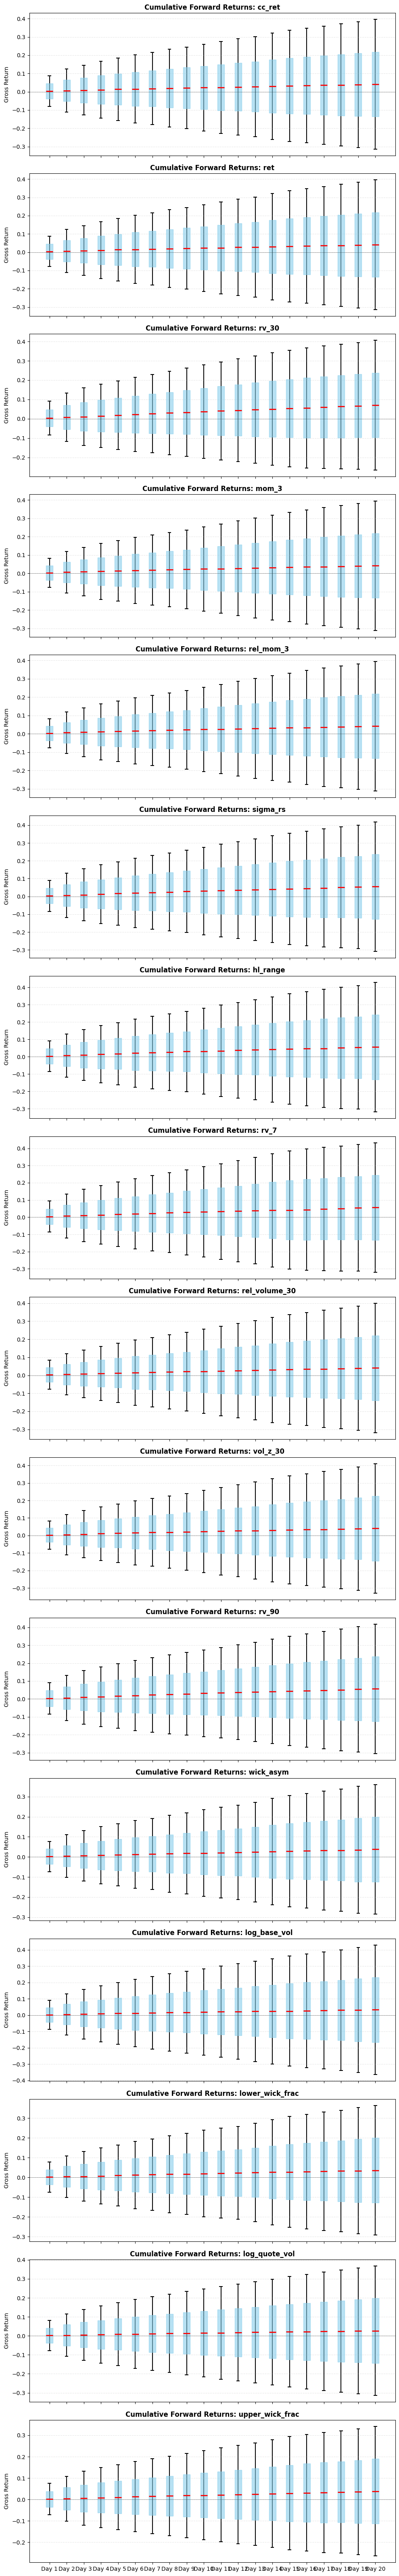

In [5]:
import matplotlib.pyplot as plt

def plot_feature_decay(summary_df, n_days):
    features = summary_df["name"].to_list()
    n_features = len(features)
    
    fig, axes = plt.subplots(n_features, 1, figsize=(10, 4 * n_features), sharex=True)
    if n_features == 1:
        axes = [axes]
        
    for idx, feature_name in enumerate(features):
        row = summary_df.filter(pl.col("name") == feature_name)
        
        days = list(range(1, n_days + 1))
        means = [row[f"fwdret_d{d}"][0] for d in days]
        stds = [row[f"fwdret_d{d}_std"][0] for d in days]
        
        ax = axes[idx]
        
        # Whiskers (+/- 2 sigma)
        ax.vlines(days, [m - 2 * s for m, s in zip(means, stds)], [m + 2 * s for m, s in zip(means, stds)], colors="black", zorder=1)
        # Whisker caps
        ax.hlines([m - 2 * s for m, s in zip(means, stds)], [d - 0.1 for d in days], [d + 0.1 for d in days], colors="black")
        ax.hlines([m + 2 * s for m, s in zip(means, stds)], [d - 0.1 for d in days], [d + 0.1 for d in days], colors="black")

        # Box (+/- 1 sigma)
        for d, m, s in zip(days, means, stds):
            ax.add_patch(plt.Rectangle((d - 0.2, m - s), 0.4, 2 * s, color="skyblue", alpha=0.6, zorder=2))
            
        # Center line (mean)
        ax.hlines(means, [d - 0.2 for d in days], [d + 0.2 for d in days], colors="red", zorder=3, lw=2)
        
        ax.set_title(f"Cumulative Forward Returns: {feature_name}", fontweight='bold')
        ax.set_ylabel("Gross Return")
        ax.axhline(0, color="black", lw=0.5, alpha=0.5)
        ax.set_xticks(days)
        ax.set_xticklabels([f"Day {d}" for d in days])
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    # plt.savefig("feature_decay.png")
    plt.show()

# Run the plot
if 'summary' in locals():
    plot_feature_decay(summary, n_days)